In [1]:
# IMPORTING REQUIRED LIBRARIES
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# List of CSV files
csv_files = [
    'Youtube01-Psy.csv',
    'Youtube02-KatyPerry.csv',
    'Youtube03-LMFAO.csv',
    'Youtube04-Eminem.csv',
    'Youtube05-Shakira.csv'
]
# Read and combine datasets
all_dataframes = []

for file in csv_files:
    df_temp = pd.read_csv(file)
    all_dataframes.append(df_temp)

# Merge all datasets
df = pd.concat(all_dataframes, ignore_index=True)

In [3]:
# DATASET OVERVIEW
print('Dataset Shape:')
print(df.shape)

print('\nColumn Names:')
print(df.columns.tolist())

print('\nData Types:')
print(df.dtypes)

print('\nFirst 5 Rows:')
print(df.head())

Dataset Shape:
(1956, 5)

Column Names:
['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'CLASS']

Data Types:
COMMENT_ID    object
AUTHOR        object
DATE          object
CONTENT       object
CLASS          int64
dtype: object

First 5 Rows:
                                    COMMENT_ID            AUTHOR  \
0  LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU         Julius NM   
1  LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A       adam riyati   
2  LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8  Evgeny Murashkin   
3          z13jhp0bxqncu512g22wvzkasxmvvzjaz04   ElNino Melendez   
4          z13fwbwp1oujthgqj04chlngpvzmtt3r3dw            GsMega   

                  DATE                                            CONTENT  \
0  2013-11-07T06:20:48  Huh, anyway check out this you[tube] channel: ...   
1  2013-11-07T12:37:15  Hey guys check out my new channel and our firs...   
2  2013-11-08T17:34:21             just for test I have to say murdev.com   
3  2013-11-09T08:28:43   me shaking my sexy

In [4]:
# FEATURE & TARGET SELECTION
# Features
X = df['CONTENT']

# Target variable
y = df['CLASS']

print('Feature Shape:', X.shape)
print('Target Shape:', y.shape)

Feature Shape: (1956,)
Target Shape: (1956,)


In [5]:
# TF-IDF VECTORIZATION
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_vectorized = vectorizer.fit_transform(X)

print('Vectorized Feature Shape:', X_vectorized.shape)

Vectorized Feature Shape: (1956, 4229)


In [6]:
# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training Data Shape:', X_train.shape)
print('Testing Data Shape:', X_test.shape)

Training Data Shape: (1564, 4229)
Testing Data Shape: (392, 4229)


In [7]:
# MODEL EVALUATION FUNCTION
def evaluate_model(model_name, y_true, y_pred, y_prob):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    print(f'\n===== {model_name} =====')

    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-Score: {f1:.4f}')
    print(f'ROC-AUC Score: {roc_auc:.4f}')

    print('\nClassification Report:')
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    return accuracy, precision, recall, f1, roc_auc


===== Logistic Regression =====
Accuracy: 0.9311
Precision: 0.9579
Recall: 0.9055
F1-Score: 0.9309
ROC-AUC Score: 0.9676

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       191
           1       0.96      0.91      0.93       201

    accuracy                           0.93       392
   macro avg       0.93      0.93      0.93       392
weighted avg       0.93      0.93      0.93       392



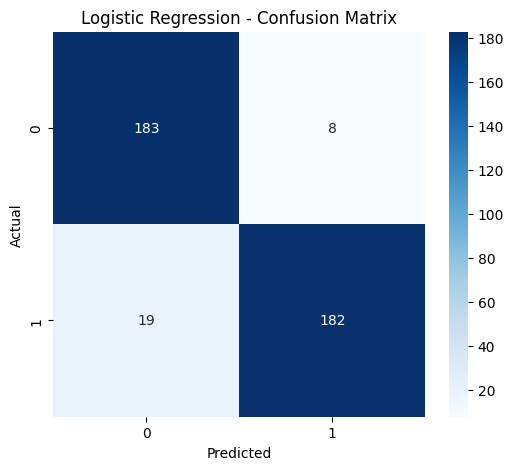

In [8]:
# LOGISTIC REGRESSION
lr_model = LogisticRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predictions
lr_predictions = lr_model.predict(X_test)

# Probability scores
lr_probabilities = lr_model.predict_proba(X_test)[:, 1]

# Evaluate
lr_results = evaluate_model(
    'Logistic Regression',
    y_test,
    lr_predictions,
    lr_probabilities
)


===== Decision Tree =====
Accuracy: 0.9464
Precision: 0.9545
Recall: 0.9403
F1-Score: 0.9474
ROC-AUC Score: 0.9466

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       191
           1       0.95      0.94      0.95       201

    accuracy                           0.95       392
   macro avg       0.95      0.95      0.95       392
weighted avg       0.95      0.95      0.95       392



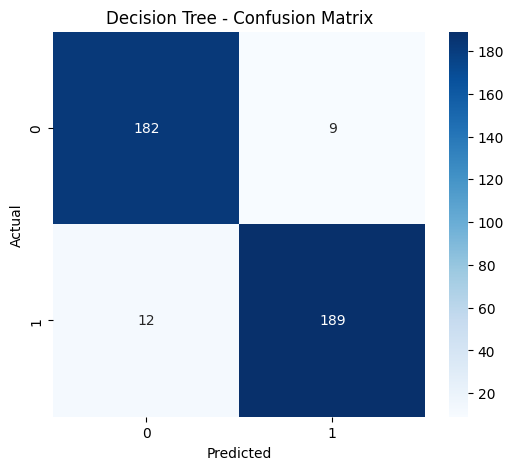

In [9]:
# DECISION TREE CLASSIFIER
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
dt_predictions = dt_model.predict(X_test)

# Probability scores
dt_probabilities = dt_model.predict_proba(X_test)[:, 1]

# Evaluate
dt_results = evaluate_model(
    'Decision Tree',
    y_test,
    dt_predictions,
    dt_probabilities
)


===== Random Forest =====
Accuracy: 0.9592
Precision: 0.9843
Recall: 0.9353
F1-Score: 0.9592
ROC-AUC Score: 0.9804

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       191
           1       0.98      0.94      0.96       201

    accuracy                           0.96       392
   macro avg       0.96      0.96      0.96       392
weighted avg       0.96      0.96      0.96       392



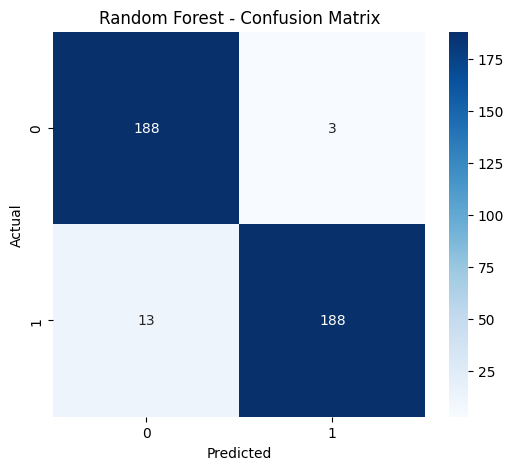

In [10]:
# RANDOM FOREST CLASSIFIER
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Probability scores
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
rf_results = evaluate_model(
    'Random Forest',
    y_test,
    rf_predictions,
    rf_probabilities
)


===== Support Vector Machine =====
Accuracy: 0.9311
Precision: 0.9628
Recall: 0.9005
F1-Score: 0.9306
ROC-AUC Score: 0.9743

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       191
           1       0.96      0.90      0.93       201

    accuracy                           0.93       392
   macro avg       0.93      0.93      0.93       392
weighted avg       0.93      0.93      0.93       392



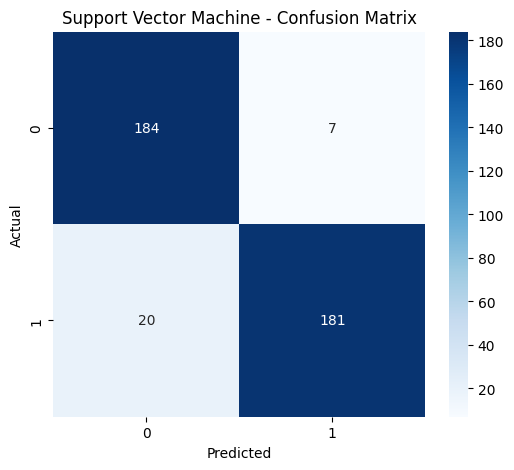

In [11]:
# SUPPORT VECTOR MACHINE
svm_model = SVC(
    probability=True,
    random_state=42
)
# Train model
svm_model.fit(X_train, y_train)

# Predictions
svm_predictions = svm_model.predict(X_test)

# Probability scores
svm_probabilities = svm_model.predict_proba(X_test)[:, 1]

# Evaluate
svm_results = evaluate_model(
    'Support Vector Machine',
    y_test,
    svm_predictions,
    svm_probabilities
)

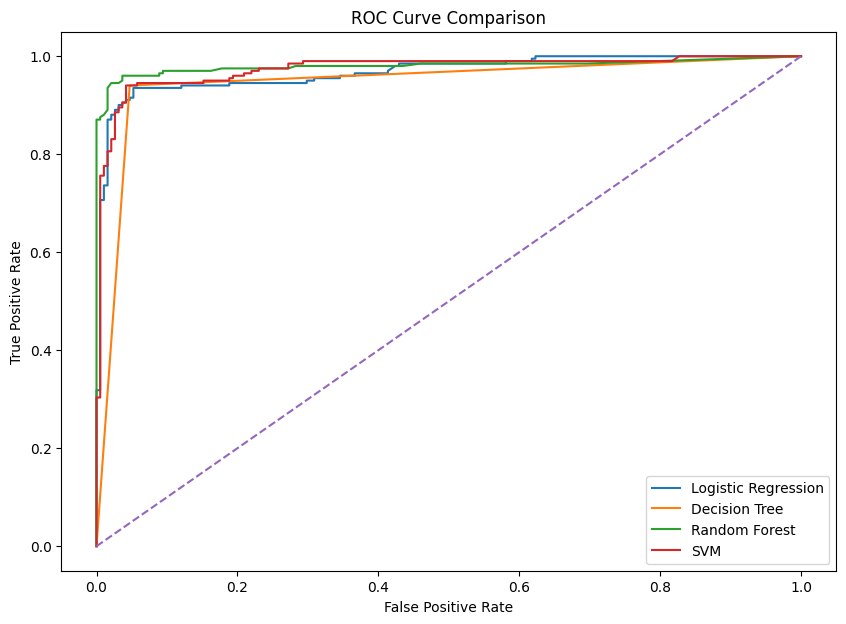

In [12]:
# ROC CURVE
models = {
    'Logistic Regression': lr_probabilities,
    'Decision Tree': dt_probabilities,
    'Random Forest': rf_probabilities,
    'SVM': svm_probabilities,
}

plt.figure(figsize=(10, 7))

for model_name, probabilities in models.items():

    fpr, tpr, _ = roc_curve(y_test, probabilities)

    plt.plot(fpr, tpr, label=model_name)

# Reference line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

In [13]:
# MODEL COMPARISON TABLE
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'SVM',
    ],

    'Accuracy': [
        lr_results[0],
        dt_results[0],
        rf_results[0],
        svm_results[0]
    ],

    'Precision': [
        lr_results[1],
        dt_results[1],
        rf_results[1],
        svm_results[1]
    ],

    'Recall': [
        lr_results[2],
        dt_results[2],
        rf_results[2],
        svm_results[2]
    ],

    'F1-Score': [
        lr_results[3],
        dt_results[3],
        rf_results[3],
        svm_results[3]
    ],

    'ROC-AUC': [
        lr_results[4],
        dt_results[4],
        rf_results[4],
        svm_results[4]
    ]
})

print(comparison_df)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.931122   0.957895  0.905473  0.930946  0.967571
1        Decision Tree  0.946429   0.954545  0.940299  0.947368  0.946589
2        Random Forest  0.959184   0.984293  0.935323  0.959184  0.980360
3                  SVM  0.931122   0.962766  0.900498  0.930591  0.974291


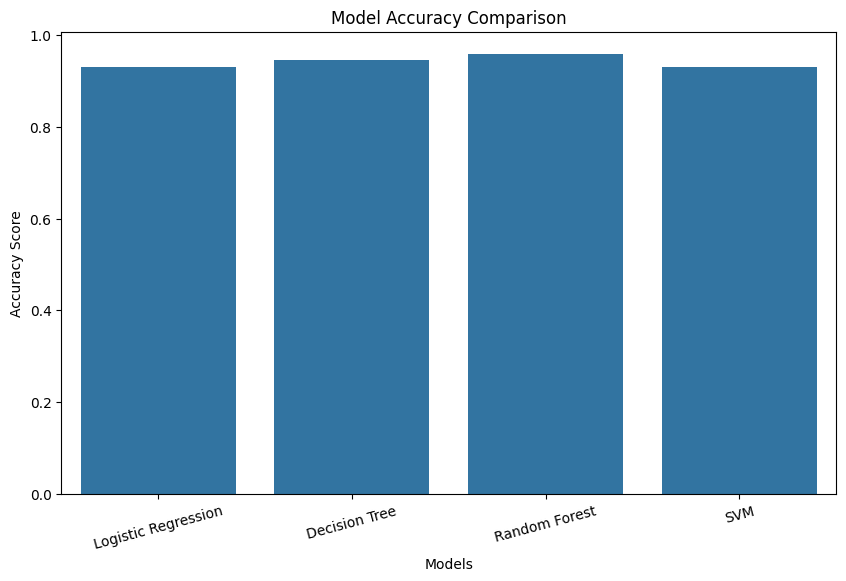

In [14]:
# ACCURACY COMPARISON BAR CHART
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy Score')

plt.xticks(rotation=15)

plt.show()